In [1]:
''' 
Steps:

- create a multiindex dataframe with the dataset_full.csv
- reduce dimentionality through PCA and from that dataframe (df_full_pca with 18 features) print the variance and plot
the first two components in 2D
- reduce dimentionality through PCA and from that dataframe (df_full_lda with 3 features) plot in 2D and then in 3D

The variance for PCA has been set to 0.90, but it can be modified with the variable comps. 
The target to plot both for PCA and LDA is 1 (stock price after one year) but it can be modified assigning the
variable target_to_use the values 2 (stock price after three years) or 3 (stock price after five years)
Seed = 123

'''

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import sys
from numpy import set_printoptions
from progressbar import progressbar
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# uncomment to show every output rows
pd.set_option('display.max_rows', 1000)

# uncomment to show every output columns
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# how the floating numbers are shown in the numpy arrays
set_printoptions(precision=3) 

# how the floating numbers are shown in pandas
pd.options.display.float_format = '{:,.3f}'.format  

np.random.seed(123)

# colors used for plotting labels
label_colors = {1:'green', 0:'red'}


In [2]:
''' Functions ''' 

def plot_two_comps(df, technique, target):
    '''
    Plot the first two dimension of a dataframe compressed with PCA or LDA in 2D
    
    :param df: a pandas dataframe with two dimension
    :param technique: PCA or LDA
    :param target: one of the three classes 
    '''
    # extract the values for X and Y
    array = df.values.T
    x = array[1:3]
    if target == 1:
        Y = array[-3]
    if target == 2:
        Y = array[-2]
    if target == 3:
        Y = array[-1]

    # compute the max and min values for both axes
    x_min, x_max = x[:, 0].min() - .5, x[:, 0].max() + .5
    y_min, y_max = x[:, 1].min() - .5, x[:, 1].max() + .5

    plt.figure(2, figsize=(8, 6))
    plt.clf()
    
    label_colors = {1:'green', 0:'red'}
    
    # Plot the training points
    if target == 1:
        plt.scatter(x[0], x[1], c=df['Class 1'].map(label_colors), cmap=plt.cm.Set1, edgecolor='k')
    if target == 2:
        plt.scatter(x[0], x[1], c=df['Class 2'].map(label_colors), cmap=plt.cm.Set1, edgecolor='k')
    if target == 3:
        plt.scatter(x[0], x[1], c=df['Class 3'].map(label_colors), cmap=plt.cm.Set1, edgecolor='k')
    
    if technique == 'PCA':
        plt.xlabel('PCA 1')
        plt.ylabel('PCA 2')
    if technique == 'LDA':
        plt.xlabel('LDA 1')
        plt.ylabel('LDA 2')

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(())
    plt.yticks(())
    plt.show()

def run_lda_with_three_targets(df):
    '''
    Run the LDA with a multiindex dataframe having three targets. 
    Create a df with a discriminant for each target and the 3 Ys
    
    :param df: a pandas dataframe
    :param comps: the number of components for PCA or the % of variance explained
    :return: the explained variance and a pandas dataframe with the LDA components    
    
    '''
    # split features and targets, extract column names and indexes
    col_names = df.columns.values

    x1 = df[col_names[0:-3]]
    Y1 = df[col_names[-3]].rename("Class 1")

    # this will be used for the 3 LDAs
    ind = x1.index.values

    x2 = df[col_names[0:-2]]
    Y2 = df[col_names[-2]].rename("Class 2")
    
    x3 = df[col_names[0:-1]]
    Y3 = df[col_names[-1]].rename("Class 3")
    
    # fit and transform
    clf = LinearDiscriminantAnalysis()
    linear_discriminants1 = clf.fit_transform(x1, Y1)
    linear_discriminants2 = clf.fit_transform(x2, Y2)
    linear_discriminants3 = clf.fit_transform(x3, Y3)

    # create 3 separate df with the linear discriminants
    lda_df1 = pd.DataFrame(data=linear_discriminants1, index=ind, columns=['LDA1'])
    lda_df2 = pd.DataFrame(data=linear_discriminants2, index=ind, columns=['LDA2'])
    lda_df3 = pd.DataFrame(data=linear_discriminants3, index=ind, columns=['LDA3'])
    
    # concatenate the 3 dfs
    lda_final_df = pd.concat([lda_df1, lda_df2], axis=1)
    lda_final_df = pd.concat([lda_final_df, lda_df3], axis=1)

    # concatenate the 3 Ys
    lda_final_df = pd.concat([lda_final_df, Y1], axis=1)
    lda_final_df = pd.concat([lda_final_df, Y2], axis=1)
    lda_final_df = pd.concat([lda_final_df, Y3], axis=1)
    
    return lda_final_df

def run_pca_with_three_targets(df, comps):
    '''
    Run the PCA with a multiindex dataframe having three targets. 
    Average explained variance and components, then create a df
    
    :param df: a pandas dataframe
    :param comps: the number of components for PCA or the % of variance explained
    :return: the explained variance and a pandas dataframe with the PCA components
    '''

    # split features and targets, extract column names and indexes
    col_names = df.columns.values
    x1 = df[col_names[0:-3]]
    Y1 = df[col_names[-3]].rename("Class 1")
    ind = x1.index.values
    
    x2 = df[col_names[0:-2]]
    Y2 = df[col_names[-2]].rename("Class 2")

    x3 = df[col_names[0:-1]]
    Y3 = df[col_names[-1]].rename("Class 3")
     
    # Fit and transform
    pca1 = PCA(n_components=comps, svd_solver='full')
    principal_components1 = pca1.fit_transform(x1)
    explained_var1 = pca1.explained_variance_ratio_
    
    pca2 = PCA(n_components=comps, svd_solver='full')
    principal_components2 = pca2.fit_transform(x2)
    explained_var2 = pca2.explained_variance_ratio_
    
    pca3 = PCA(n_components=comps, svd_solver='full')
    principal_components3 = pca3.fit_transform(x3)
    explained_var3 = pca3.explained_variance_ratio_
    
    # Sum and average the explained variance
    explained_var = ( explained_var1 + explained_var2 + explained_var3 ) / 3

    # create a list with the component names
    cols = []
    #for i in range(1, comps + 1):
    for i in range(1, pca1.n_components_ + 1):
        cols.append('Eigenvector %d' % i)

    # Average the components and create a new dataframe with the them
    principal_components = ( principal_components1 + principal_components2 + principal_components3 ) / 3
    pca_df = pd.DataFrame(data=principal_components, index=ind, columns=cols)

    # Concat the pca_df with Y
    final_df = pd.concat([pca_df, Y1], axis=1)
    final_df = pd.concat([final_df, Y2], axis=1)
    final_df = pd.concat([final_df, Y3], axis=1)

    return explained_var, final_df

def create_multiindex_dataframe(filename, index_list):
    '''
    Create a multiindex dataframe from a csv or xlsx file
    :param filename: a csv or xlsx file
    :param index_list: number of column levels, usually [0, 1]
    :return: a multiindex dataframe
    '''

    if "xlsx" in filename:
        df = pd.read_excel(filename, header=index_list, index_col=0)
        df = pd.DataFrame(df)
    elif "csv" in filename:
        df = pd.read_csv(filename, header=index_list, index_col=0)
        df = pd.DataFrame(df)

    return df


In [3]:
''' Create dataframes and global variables '''

file_full = 'dataset_full.csv'

index_list = [0, 1]

# create the dataframe 
df_full = create_multiindex_dataframe(file_full, index_list)


Explained Variance per each component = [0.421 0.14  0.047 0.046 0.041 0.033 0.028 0.024 0.023 0.018 0.015 0.014
 0.012 0.01  0.01  0.008 0.007 0.007]

      Eigenvector 1  Eigenvector 2  Eigenvector 3  Eigenvector 4  Eigenvector 5  Eigenvector 6  Eigenvector 7  Eigenvector 8  Eigenvector 9  Eigenvector 10  Eigenvector 11  Eigenvector 12  Eigenvector 13  Eigenvector 14  Eigenvector 15  Eigenvector 16  Eigenvector 17  Eigenvector 18  Class 1  Class 2  Class 3
AAN          -4.422          0.792         -0.372         -0.231          2.208         -0.307          0.129         -0.746         -0.181           0.680          -0.426           0.140           0.169           0.042           0.129          -0.007          -0.255           0.301        1        1        0
AAP          -2.517         -0.332         -0.979         -0.053          2.027         -0.281         -0.870         -0.954          0.774           0.263           0.027           0.191          -0.251           0.172       

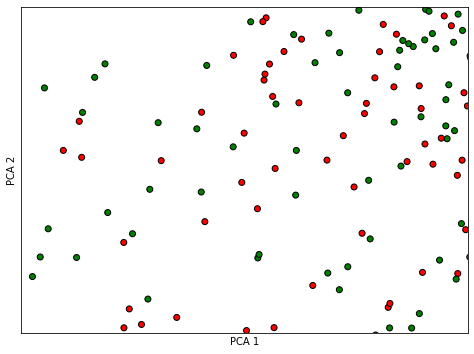

In [4]:
''' Call the PCA function, print the variance and plot the components '''

comps = 0.90
tech = 'PCA'

# the function returns the variance and a new dataframe with the components used to reach 0.90
pca_results = run_pca_with_three_targets(df_full, comps)
pca_variance = pca_results[0]
df_full_pca = pca_results[1]

# print the results
print('Explained Variance per each component = ' + str(pca_variance))
print()
print(df_full_pca.head(5))

# chose the target to use with the plot
target_to_use = 3

# plot the first two components in 2D
plot_two_comps(df_full_pca, tech, target_to_use)


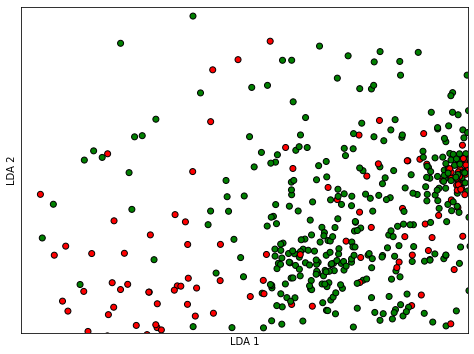

In [5]:
''' Call the LDA function, create a dataframe with 3 variables and 3 targets and plot the first two components '''

tech = 'LDA'

# the function returns a new dataframe
df_full_lda = run_lda_with_three_targets(df_full)

# separate x and Ys
x_full_lda = df_full_lda.loc[:, ["LDA1", "LDA2", "LDA3"] ]
Y1_full_lda = df_full_lda.loc[:, "Class 1"]
Y2_full_lda = df_full_lda.loc[:, "Class 2"]
Y3_full_lda = df_full_lda.loc[:, "Class 3"]

# chose the target to use with the plot
target_to_use = 1

# plot the first two components in 2D
if target_to_use == 1:
    df_train_lda_to_plot = pd.concat([x_full_lda, Y1_full_lda], axis=1)
if target_to_use == 2:
    df_train_lda_to_plot = pd.concat([x_full_lda, Y2_full_lda], axis=1)
if target_to_use == 3:
    df_train_lda_to_plot = pd.concat([x_full_lda, Y3_full_lda], axis=1)


plot_two_comps(df_train_lda_to_plot, tech, target_to_use) 


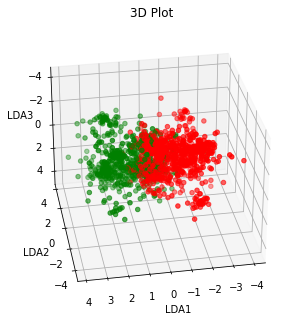

In [6]:
''' Plot in 3D using one of the 3 targets '''

# chose the target to use with the plot
target_to_use = 1

if target_to_use == 1:
    Y = Y1_full_lda
if target_to_use == 2:
    Y = Y2_full_lda
if target_to_use == 3:
    Y = Y3_full_lda

plot = Axes3D(plt.figure(1), elev=-150, azim=100)  # Create frame for scatter plot

if target_to_use == 1:
    plot.scatter(x_full_lda['LDA1'], x_full_lda['LDA2'], x_full_lda['LDA3'], c=df_full_lda['Class 1'].map(label_colors), cmap=plt.cm.bwr)
if target_to_use == 2:
    plot.scatter(x_full_lda['LDA1'], x_full_lda['LDA2'], x_full_lda['LDA3'], c=df_full_lda['Class 2'].map(label_colors), cmap=plt.cm.bwr)
if target_to_use == 3:
    plot.scatter(x_full_lda['LDA1'], x_full_lda['LDA2'], x_full_lda['LDA3'], c=df_full_lda['Class 3'].map(label_colors), cmap=plt.cm.bwr)

plot.set_title("3D Plot")
plot.set_xlabel('LDA1')
plot.set_ylabel('LDA2')
plot.set_zlabel('LDA3')
plt.show()

